In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 10
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcMnBhY1xEb2N1bWVudHNcU29TZTI2XE1MX2Vjb25vbWlzdHNcU3R1ZGVudF9TZXNzaW9uc1xPdXJzX1M3XEdF'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\2pac\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\importlib\\_bootstrap.py": 1777369021.9120054, "C:\\Users\\2pac\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\importlib\\_bootstrap_external.py": 1777369021.9130049, "C:\\Users\\2pac\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\zipimport.py": 1777369021.642028, "C:\\Users\\2pac\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\codecs.py": 1777369021.5398536, "C:\\Users\\2pac\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\encodings\\aliases.py": 1777369021.7270694, "C:\\Users\\2pac\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\encodings\\_win_cp_codecs.py": 1777369021.8265994, "C:\\Users\\2pac\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\encodings\\__init__.py": 1777369021.8281057, "C:\\Users\\2pac\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\encodings\\utf_8.py": 1777369021.8239834, "C:\\Users\\2pac\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\abc.py": 1777369021.5297773, "C:\\Users\\2pac

In [2]:
#| include: false
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch, Circle, FancyBboxPatch
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')
import math
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import KFold
import numpy as np
import plotly.graph_objects as go
import IPython.display 
from IPython.display import HTML


# ── Global aesthetic settings (university light theme) ─────────────────────
BG      = "#fafaf8"        # warm off-white
CARD    = "#f0f2f5"        # soft grey card
ACCENT1 = "#1a3a6b"        # deep navy
ACCENT2 = "#1d5fa6"        # university blue
ACCENT3 = "#b5282a"        # academic red
ACCENT4 = "#2d7a4f"        # forest green
YELLOW  = "#b8860b"        # dark gold
TEXT    = "#1a1a2e"        # near-black
MUTED   = "#5a6272"        # slate grey

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    "#ffffff",
    "axes.edgecolor":    "#d0d5dd",
    "axes.labelcolor":   TEXT,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "text.color":        TEXT,
    "grid.color":        "#d0d5dd",
    "grid.linewidth":    0.6,
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "lines.linewidth":   2.2,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

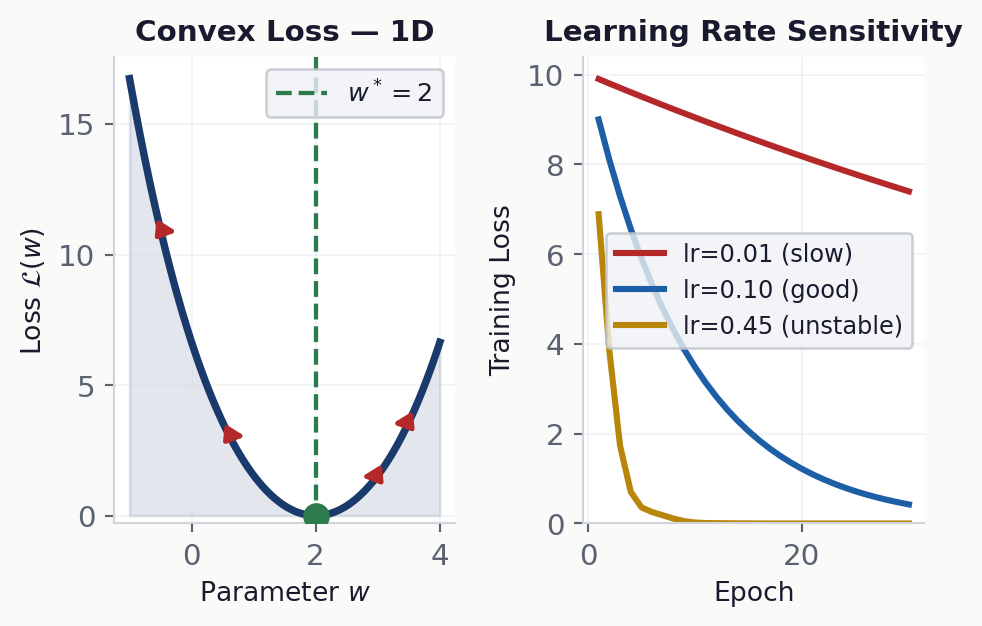

In [3]:
#| echo: false

fig, axes = plt.subplots(1, 2, figsize=(5.25, 3.45))
fig.patch.set_facecolor(BG)

ax = axes[0]
ax.set_facecolor('#ffffff')
w_vals = np.linspace(-1, 4, 300)
loss_vals = 0.5 * (w_vals - 2)**2 * 3 + 0.4*(w_vals - 2)**4 * 0.1

ax.plot(w_vals, loss_vals, color=ACCENT1, lw=2.8)
ax.fill_between(w_vals, 0, loss_vals, alpha=0.12, color=ACCENT1)
ax.axvline(2.0, color=ACCENT4, ls="--", lw=1.6, label="$w^* = 2$")
ax.plot(2.0, 0.0, "o", color=ACCENT4, ms=9, zorder=5)

for ww in [-0.5, 0.6, 3.5, 3.0]:
    lw_val = 0.5 * (ww - 2)**2 * 3 + 0.4*(ww-2)**4*0.1
    grad = (ww-2)*3 + 0.4*(ww-2)**3
    ax.annotate("", xy=(ww - 0.35*np.sign(grad), lw_val - 0.08),
                xytext=(ww, lw_val),
                arrowprops=dict(arrowstyle="-|>", color=ACCENT3,
                                lw=1.8, mutation_scale=13))

ax.set_xlabel("Parameter $w$", fontsize=10)
ax.set_ylabel("Loss $\\mathcal{L}(w)$", fontsize=10)
ax.set_title("Convex Loss — 1D", fontsize=11)
ax.legend(fontsize=9.5, facecolor=CARD, edgecolor="#c0c5cc", labelcolor=TEXT)
ax.set_ylim(bottom=-0.3)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.set_facecolor('#ffffff')
epochs_lr = np.arange(1, 31)
for lr, col, lbl in [(0.01, ACCENT3, "lr=0.01 (slow)"),
                      (0.1,  ACCENT2, "lr=0.10 (good)"),
                      (0.45, YELLOW,  "lr=0.45 (unstable)")]:
    losses_lr = [10 * (1 - lr)**e for e in epochs_lr]
    if lr == 0.45:
        losses_lr = [10 * abs(1 - lr)**e * (1 + 0.3*np.sin(e)) for e in epochs_lr]
    ax2.plot(epochs_lr, losses_lr, color=col, lw=2.3, label=lbl)

ax2.set_xlabel("Epoch", fontsize=10)
ax2.set_ylabel("Training Loss", fontsize=10)
ax2.set_title("Learning Rate Sensitivity", fontsize=11)
ax2.legend(fontsize=9, facecolor=CARD, edgecolor="#c0c5cc", labelcolor=TEXT)
ax2.set_ylim(bottom=0)
ax2.grid(True, alpha=0.3)

fig.tight_layout(pad=1.2)
plt.savefig("fig_loss_lr.png", dpi=140, bbox_inches="tight", facecolor=BG)
plt.show()

In [4]:
#|echo: false

# Grid over x and y
xs = np.linspace(-2, 2, 80)
ys = np.linspace(-2, 2, 80)
X, Y = np.meshgrid(xs, ys)

# Simple predictor: f(x) = x
fX = X

# Pointwise loss
loss = (Y - fX) ** 2

# Simple joint density p(x,y) = p(x)p(y)
sigma_x = 1.0
sigma_y = 1.0

px = (1 / np.sqrt(2 * np.pi * sigma_x**2)) * np.exp(-(X**2) / (2 * sigma_x**2))
py = (1 / np.sqrt(2 * np.pi * sigma_y**2)) * np.exp(-(Y**2) / (2 * sigma_y**2))
p_xy = px * py

# Local contribution to expected loss
Z = loss * p_xy

fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z,
            colorscale='RdBu',
            reversescale=True,
            showscale=True,
            colorbar=dict(
                thickness=12,
                len=0.65
            )
        )
    ]
)   

fig.update_layout(
    paper_bgcolor="#fafaf8",    
    title=r"",
    scene=dict(
        bgcolor="#fafaf8",
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="L(w,b) · p(x)",
        camera=dict(
            eye=dict(x=1.6, y=1.6, z=0.9)
        )
    ),
    width=600,
    height=460,
    margin=dict(l=0, r=0, t=0, b=0)
)

# Show in notebook
fig.show()

# Export for Reveal.js
fig.write_html(
    "expected_loss_surface.html",
    include_plotlyjs=True,   # fully self-contained
    full_html=True
)

In [5]:
#| echo: false
n_train, n_test = 400, 100
max_degree = 8
true_w = torch.zeros(max_degree)
true_w[0:5] = torch.tensor([-0.2, 0.4, 0.4, -1.194, 0.672], dtype=torch.float32)  # cubic truth

In [6]:
#| echo: false
## Generate features
features = torch.randn(n_train + n_test, 1)   # N(0,1)
features = features * 2.4 + 3.5               # roughly mean 1.5, std 2  (covers ~[-3, 6])
features = torch.clamp(features, -8.0, 8)   # hard truncate to [-3, 6]

perm = torch.randperm(features.shape[0])
features = features[perm]
perm = torch.randperm(features.shape[0])
features = features[perm]

# Center x around the middle of the interval
x0 = 1.5                        # midpoint of [-3,6]
x_centered = features - x0

poly_features = torch.cat(
    [x_centered ** i / math.factorial(i) for i in range(max_degree)],
    dim=1
)

# generate labels from features and truth
labels = poly_features @ true_w
labels += 0.42 * torch.randn_like(labels)

## put them in your working sets
X_train, X_test = poly_features[:n_train], poly_features[n_train:]
y_train, y_test = labels[:n_train], labels[n_train:]
x_train_raw, x_test_raw = features[:n_train], features[n_train:]

In [7]:
#| echo: false

## get the losses
def evaluate_loss(model, X, y):
    model.eval()
    with torch.no_grad():
        pred = model(X)
        return nn.MSELoss()(pred, y).item()

## fit the model
def fit_polynomial(degree, num_epochs=19, lr=0.0001):
    model = nn.Linear(degree, 1, bias=False)
    loss_fn = nn.MSELoss()
    opt = torch.optim.SGD(model.parameters(), lr=lr)

    ds = TensorDataset(X_train[:, :degree], y_train)
    dl = DataLoader(ds, batch_size=min(10, n_train), shuffle=True)

    train_losses, test_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        for xb, yb in dl:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

        train_losses.append(evaluate_loss(model, X_train[:, :degree], y_train))
        test_losses.append(evaluate_loss(model, X_test[:, :degree], y_test))

    return model, train_losses, test_losses

In [8]:
#| echo: false
results = {}
for degree in [3, 4, 5, 7]:
    results[degree] = fit_polynomial(degree)

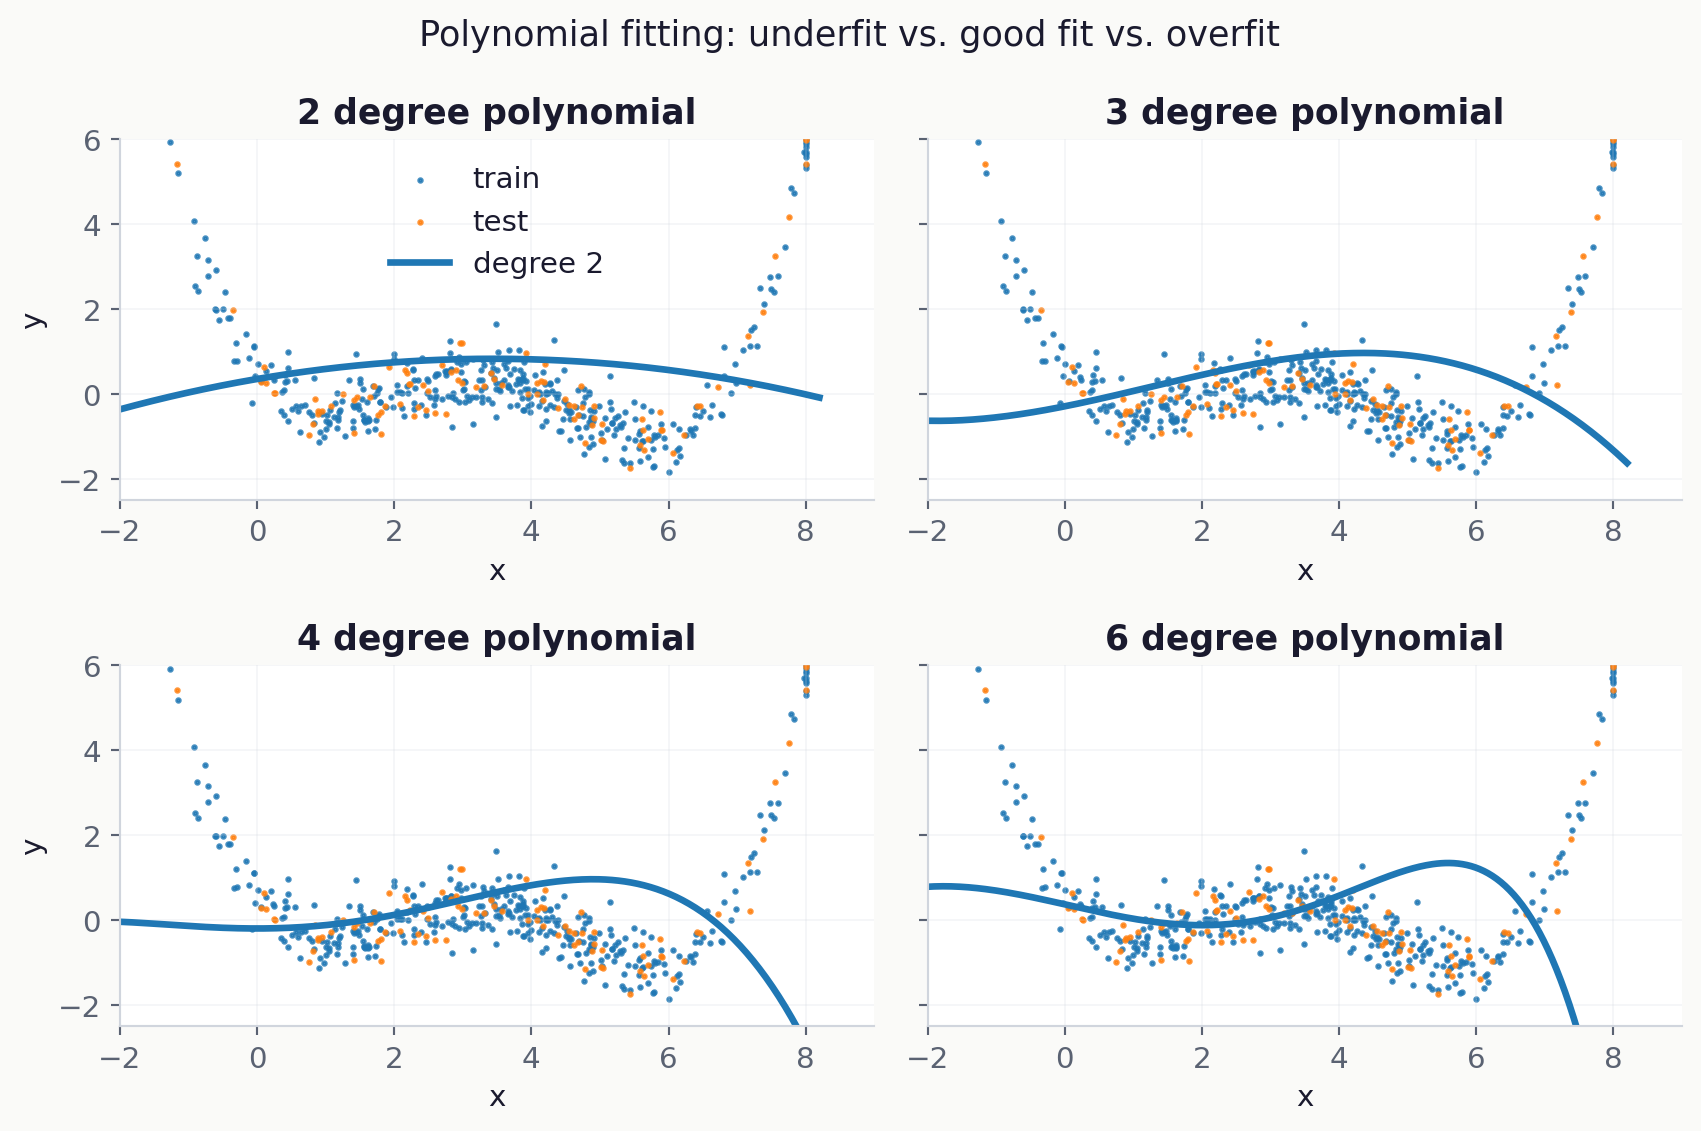

In [9]:
#| echo: false
x_grid = torch.linspace(features.min().item() - 0.2,
                        features.max().item() + 0.2, 400).reshape(-1, 1)
grid_poly = torch.cat(
    [x_grid ** i / math.factorial(i) for i in range(max_degree)],
    dim=1
)

fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharey=True)
axes = axes.ravel()

# Fixed view window, same for all panels
for ax in axes:
    ax.set_xlim(-2.0, 9.0)   # x-range you care about
    ax.set_ylim(-2.5, 6)   # fixed y-range (e.g. just a bit beyond your y extremes)

for ax, degree in zip(axes, [3, 4, 5, 7]):
    model, train_losses, test_losses = results[degree]
    with torch.no_grad():
        y_hat = model(grid_poly[:, :degree]).numpy()

    ax.scatter(x_train_raw.numpy(), y_train.numpy(), s=2, alpha=0.8, label="train")
    ax.scatter(x_test_raw.numpy(), y_test.numpy(), s=2, alpha=0.8, label="test")
    ax.plot(x_grid.numpy(), y_hat, lw=2.5, label=f"degree {degree-1}")
    ax.set_title(f"{degree-1} degree polynomial")
    ax.set_xlabel("x")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("y")
axes[2].set_ylabel("y")
axes[0].legend(frameon=False)
fig.suptitle("Polynomial fitting: underfit vs. good fit vs. overfit", y=0.98)
fig.tight_layout()
plt.show()

In [10]:
#| echo: false
import pandas as pd
import numpy as np

# Collect all estimated weights
estimated_weights = {}
max_deg = max(results.keys())
max_k = max_deg  # max number of coefficients we ever see

for degree in sorted(results.keys()):
    model, train_losses, test_losses = results[degree]
    w_hat = model.weight.detach().cpu().reshape(-1).numpy()
    estimated_weights[degree] = np.round(w_hat,4)

# ensure consistent ordering of columns
degrees = [3, 4, 5, 7]

# build DataFrame, padding shorter columns with NaN
df = pd.DataFrame(
    {deg: pd.Series(estimated_weights[deg]) for deg in degrees}
)

# set row index as generic weight index (0..max_k-1)
df.index = np.arange(df.shape[0])
df.index.name = "w"

def fmt_trunc(v):
    # If v is NaN, show empty string or 'NaN'
    if isinstance(v, float) and math.isnan(v):
        return ""  # or "NaN"
    # truncate to 4 decimals
    v_trunc = int(v * 10_000) / 10_000.0
    s = f"{v_trunc:.2f}"
    s = s.rstrip("0").rstrip(".")
    return s

styled = (
    df.style
      .format(fmt_trunc)
)

styled

,3,4,5,7
w,,,,
0,0.35,-0.29,-0.19,0.37
1,0.28,0.32,0,-0.37
2,-0.08,0.1,0.14,-0.01
3,,-0.08,0.06,0.21
4,,,-0.07,-0.01
5,,,,-0.02
6,,,,-0.04


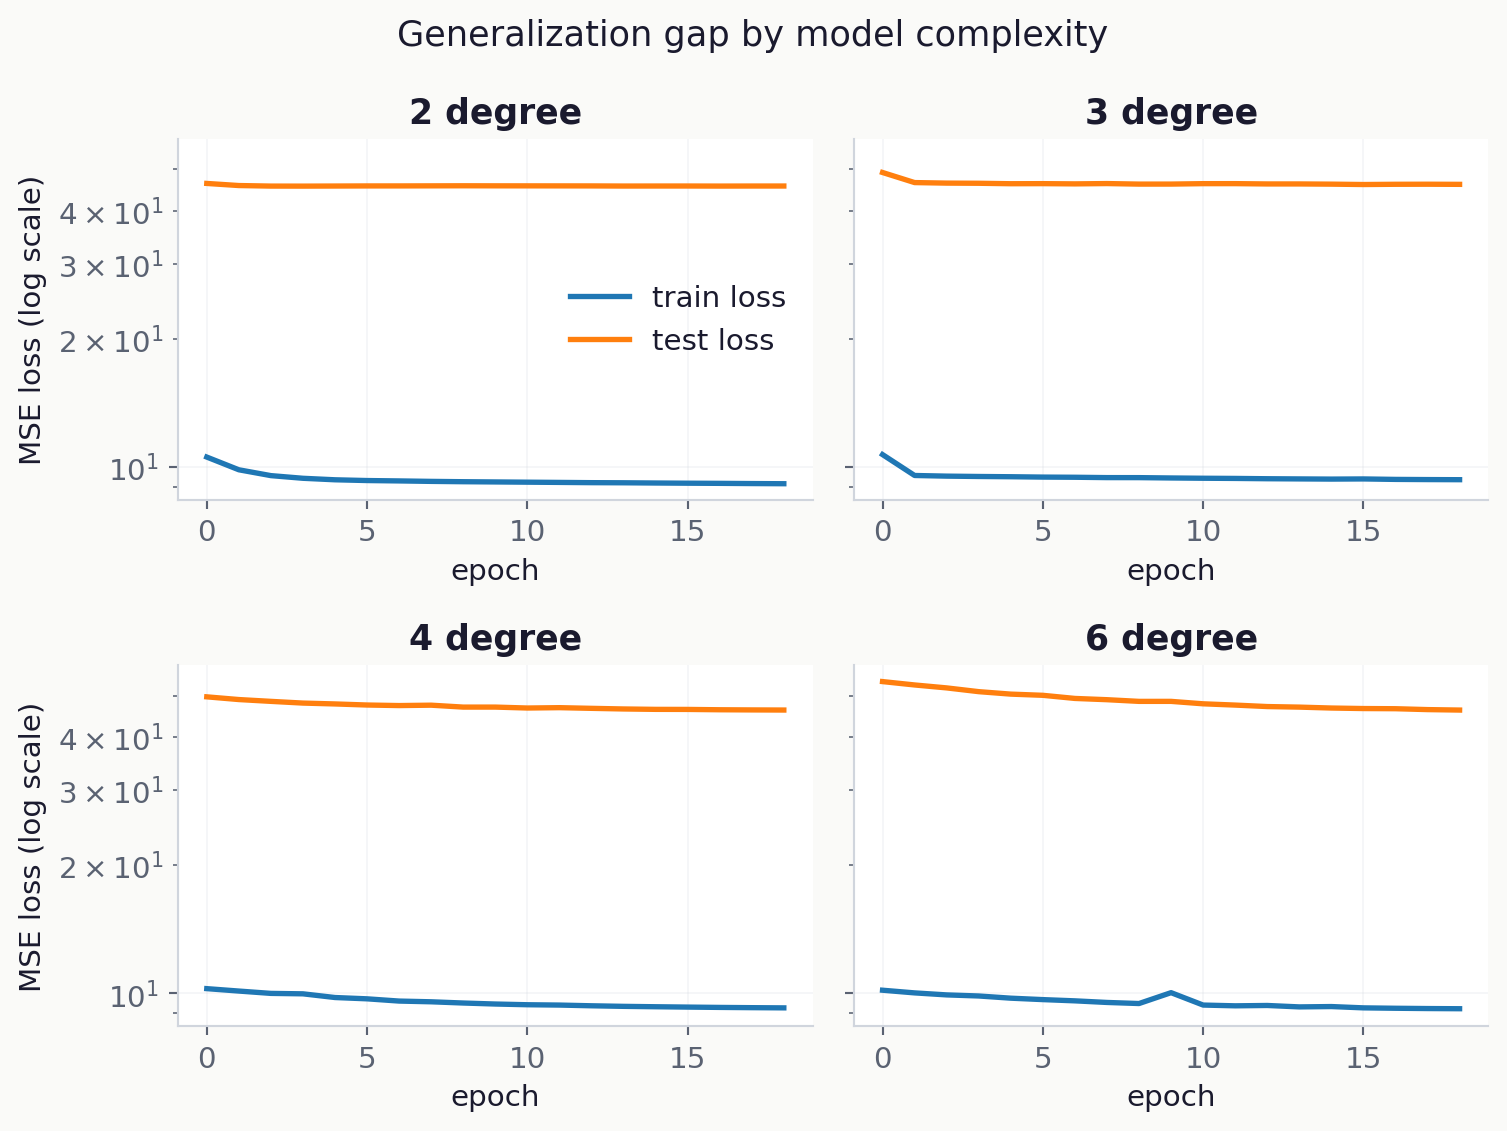

In [11]:
#| echo: false
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharey=True)
axes = axes.ravel()

for ax, degree in zip(axes, [3, 4, 5, 7]):
    model, train_losses, test_losses = results[degree]
    ax.plot(train_losses, lw=2, label="train loss")
    ax.plot(test_losses, lw=2, label="test loss")
    ax.set_title(f"{degree-1} degree")
    ax.set_xlabel("epoch")
    ax.set_yscale("log")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("MSE loss (log scale)")
axes[2].set_ylabel("MSE loss (log scale)")
axes[0].legend(frameon=False)

fig.suptitle("Generalization gap by model complexity", y=0.98)
fig.tight_layout()
plt.show()

In [12]:
#| echo: false
K = 5
n_samples = poly_features.shape[0]
indices = np.arange(n_samples)
np.random.seed(0)  # for reproducibility
np.random.shuffle(indices)

folds = np.array_split(indices, K)

In [13]:
#| echo: false
def fit_polynomial_on_split(X_all, y_all, train_idx, val_idx, degree,
                            num_epochs=30, lr=0.0001):
    model = nn.Linear(degree, 1, bias=False)
    loss_fn = nn.MSELoss()
    opt = torch.optim.SGD(model.parameters(), lr=lr)

    X_train = X_all[train_idx, :degree]
    y_train = y_all[train_idx]
    X_val   = X_all[val_idx, :degree]
    y_val   = y_all[val_idx]

    ds = TensorDataset(X_train, y_train)
    dl = DataLoader(ds, batch_size=min(10, len(train_idx)), shuffle=True)

    for epoch in range(num_epochs):
        model.train()
        for xb, yb in dl:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

    # one validation MSE at the end
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = loss_fn(val_pred, y_val).item()

    return model, val_loss

In [14]:
#| echo: false
degrees = [3, 4, 5, 7]  # or any list you like
cv_results = {deg: [] for deg in degrees}

for degree in degrees:
    for k in range(K):
        val_idx = folds[k]
        train_idx = np.concatenate([folds[j] for j in range(K) if j != k])

        model, val_loss = fit_polynomial_on_split(
            poly_features, labels, train_idx, val_idx, degree
        )
        cv_results[degree].append(val_loss)

print("5-fold cross-validation MSE per degree:\n")

5-fold cross-validation MSE per degree:



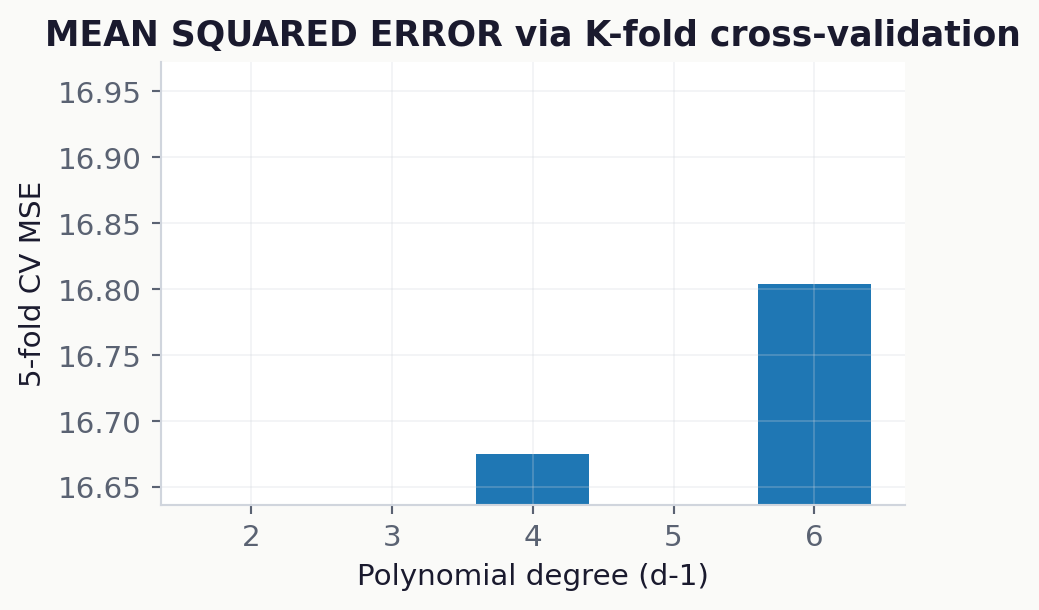

In [15]:
#| echo: false
maxloss = np.max(np.mean(cv_results[degree]))
minloss = np.min(np.mean(cv_results[degree]))

top = maxloss + maxloss/100
floor = minloss - maxloss/100

plt.figure(figsize=(5, 3))
plt.bar([d-1 for d in degrees],
         [np.mean(cv_results[d]) for d in degrees])
plt.ylim(floor,top)
plt.xlabel("Polynomial degree (d-1)")
plt.ylabel("5-fold CV MSE")
plt.grid(alpha=0.3)
plt.title("MEAN SQUARED ERROR via K-fold cross-validation")
plt.show()

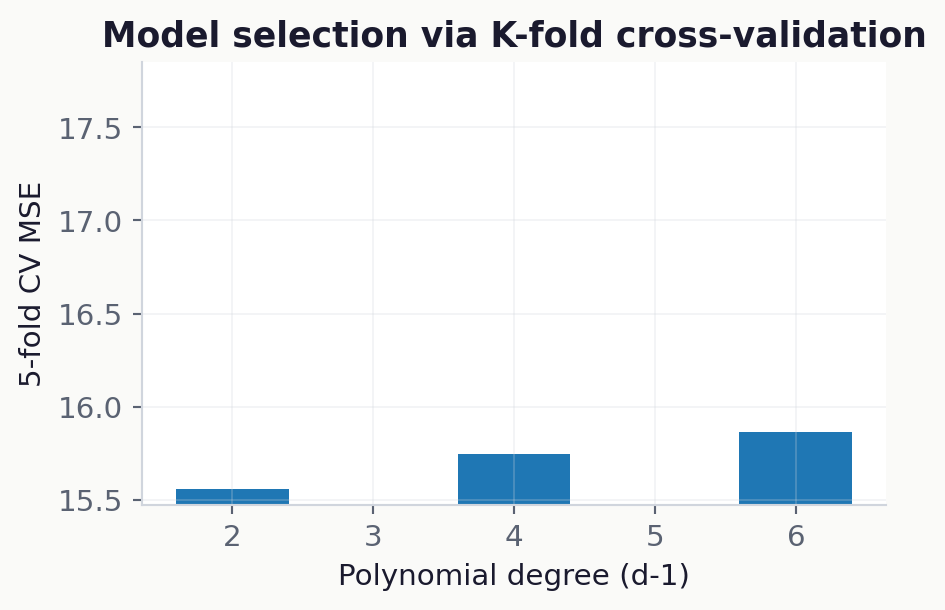

In [16]:
#| echo: false

maxloss_std = np.max(np.std(cv_results[degree]))
minloss_std = np.min(np.std(cv_results[degree]))

top_std = maxloss_std + maxloss_std/8
floor_std = minloss_std - maxloss_std/40

plt.figure(figsize=(5, 3))
plt.bar([d-1 for d in degrees],
         [np.std(cv_results[d]) for d in degrees])
plt.ylim(floor_std,top_std)
plt.xlabel("Polynomial degree (d-1)")
plt.ylabel("5-fold CV MSE")
plt.grid(alpha=0.3)
plt.title("Model selection via K-fold cross-validation")
plt.show()

In [17]:
#| echo: false
for degree in degrees:
    losses = cv_results[degree]
    mean_loss = np.mean(losses)
    std_loss = np.std(losses)
    print(f"degree {degree-1}: mean MSE={mean_loss:.4f}, std={std_loss:.4f}")

degree 2: mean MSE=16.5264, std=15.5571
degree 3: mean MSE=16.5406, std=15.4580
degree 4: mean MSE=16.6753, std=15.7483
degree 6: mean MSE=16.8042, std=15.8672


In [18]:
#| echo: false
def fit_polynomial_on_split(X_all, y_all, train_idx, val_idx, degree,
                            num_epochs=30, lr=0.0002, wd=0.0):
    model = nn.Linear(degree, 1, bias=False)
    loss_fn = nn.MSELoss()

    # This line implements the update rule from the chapter:
    # it minimizes L(w,b) + (lambda/2)||w||^2
    opt = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=wd)

    X_train = X_all[train_idx, :degree]
    y_train = y_all[train_idx]
    X_val   = X_all[val_idx, :degree]
    y_val   = y_all[val_idx]

    ds = TensorDataset(X_train, y_train)
    dl = DataLoader(ds, batch_size=min(10, len(train_idx)), shuffle=True)

    for epoch in range(num_epochs):
        model.train()
        for xb, yb in dl:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = loss_fn(val_pred, y_val).item()

    return model, val_loss

In [19]:
#| echo: false
K = 5
# folds = np.array_split(indices, K)   # you already defined this earlier
degrees = [3, 4, 5, 7]
lambdas = [1e-3, 1e-2, 1e-1, 2e-1]  # e.g. no WD, mild WD, stronger WD

cv_results = {deg: {wd: [] for wd in lambdas} for deg in degrees}
best_models = {deg: {wd: None for wd in lambdas} for deg in degrees}


for degree in degrees:
    for wd in lambdas:
        best_loss = float("inf")
        for k in range(K):
            val_idx = folds[k]
            train_idx = np.concatenate([folds[j] for j in range(K) if j != k])

            model, val_loss = fit_polynomial_on_split(
                poly_features, labels,
                train_idx, val_idx,
                degree,
                num_epochs=30, lr=0.0001, wd=wd
            )
            cv_results[degree][wd].append(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            best_models[degree][wd] = model

tables = {}  # degree -> DataFrame

for degree in degrees:
    rows = []
    for wd in lambdas:
        mean_loss = np.mean(cv_results[degree][wd])
        rows.append({"λ": wd, "MSE": mean_loss})
    df_deg = pd.DataFrame(rows)
    tables[degree] = df_deg

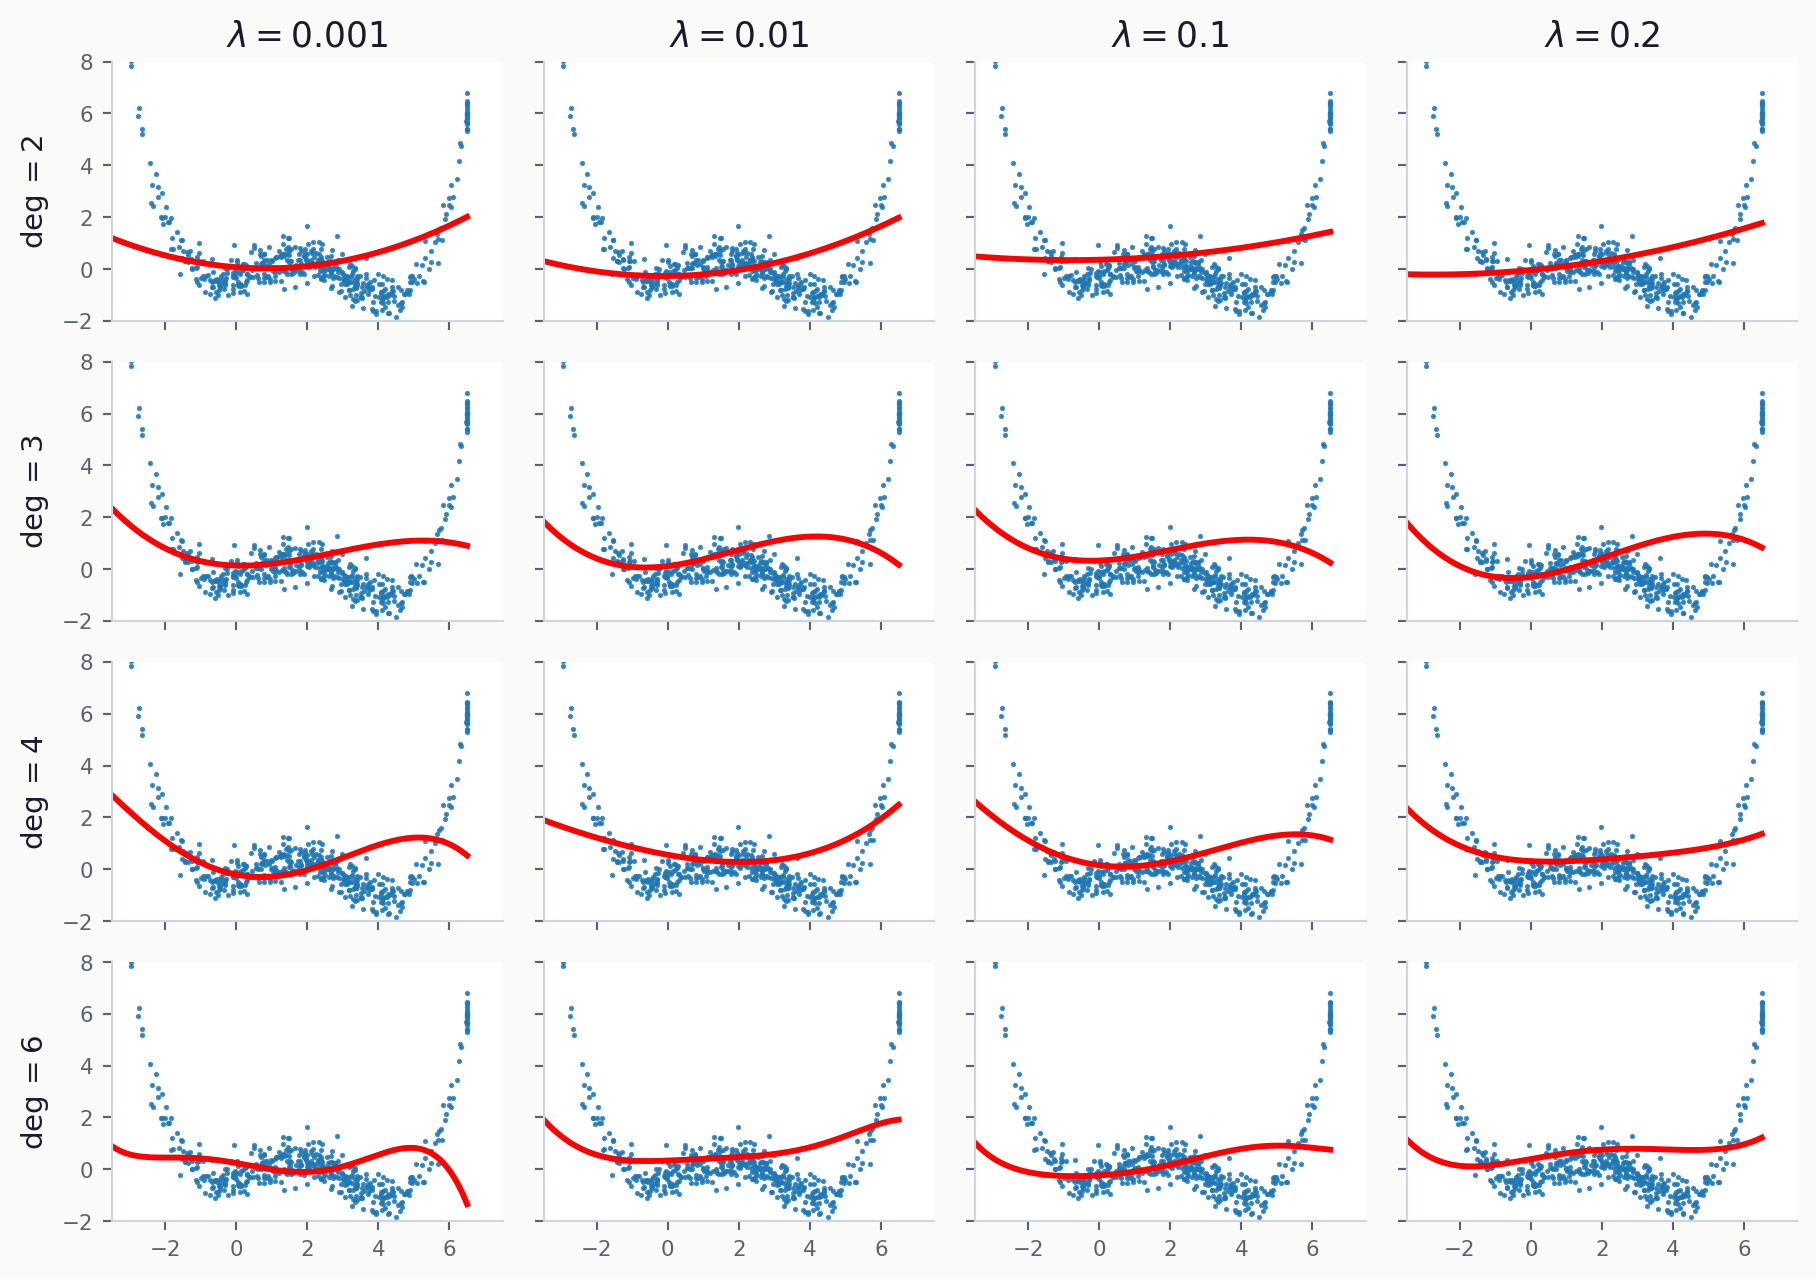

In [20]:
#| echo: false
x_all = x_centered.cpu().numpy()  # original 1D inputs, shape (N,)
y_all = labels

x_plot = np.linspace(x_all.min(), x_all.max(), 200)
x_plot_centered = torch.tensor(x_plot, dtype=torch.float32).view(-1, 1)

X_plot_poly = torch.cat(
    [x_plot_centered ** i / math.factorial(i) for i in range(max_degree)],
    dim=1
)

fig, axes = plt.subplots(
    nrows=len(degrees),
    ncols=len(lambdas),
    figsize=(2.4*len(lambdas), 1.7*len(degrees)),
    
    sharex=True, sharey=True
)

for i, degree in enumerate(degrees):
    for j, wd in enumerate(lambdas):
        ax = axes[i, j]
        model = best_models[degree][wd]

        with torch.no_grad():
            y_hat = model(X_plot_poly[:, :degree]).numpy()

        ax.scatter(x_all, y_all.numpy(), s=1, alpha=0.8)
        ax.plot(x_plot, y_hat, color="red")

        ax.tick_params(axis="both", which="major", labelsize=8)

# column headers (lambdas) – put on top row
for j, wd in enumerate(lambdas):
    axes[0, j].set_title(rf"$\lambda={wd}$")

# row headers (degrees) – use ylabels or fig-side text
for i, degree in enumerate(degrees):
    # option A: use y-axis label
    axes[i, 0].set_ylabel(rf"$\deg={degree-1}$")

    # or option B: text in the left margin
    # fig.text(0.04, 
    #          axes[i, 0].get_position().centery,
    #          rf"deg={degree}", va="center", ha="right")

plt.tight_layout()
plt.ylim(-2, 8)
plt.xlim(-3.5, 7.5)
plt.show()

In [21]:
#| echo: false
tables[3].style.hide(axis="index")

λ,MSE
0.001000,16.608523
0.010000,16.519088
0.100000,16.602158
0.200000,16.638068


In [22]:
#| echo: false
tables[4].style.hide(axis="index").hide(axis="columns")

0.001000,16.486687
0.010000,16.716331
0.100000,16.682840
0.200000,16.734665


In [23]:
#| echo: false
tables[4].style.hide(axis="index").hide(axis="columns")

0.001000,16.486687
0.010000,16.716331
0.100000,16.682840
0.200000,16.734665


In [24]:
#| echo: false
tables[7].style.hide(axis="index").hide(axis="columns")

0.001000,16.515021
0.010000,17.389254
0.100000,16.906603
0.200000,16.620840
